# Lab02 - Markov Decision Process, Hàm giá trị và Dynamic Programming

**Học phần:** Học tăng cường – Reinforcement Learning
**Họ tên:** ...........................
**MSSV:** ...........................
**Lớp:** ...........................

Notebook này tổng hợp lại pipeline của Lab02 (import các hàm từ
`src/mdp_utils.py` và các bài `bai01.py` ... `bai36.py`), chạy các thí
nghiệm chính, hiển thị biểu đồ, và trả lời 25 câu hỏi lý thuyết yêu cầu
trong đề bài.

In [1]:
import sys, os
sys.path.append(os.path.abspath("../src"))

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

from mdp_utils import (
    ACTION_NAMES, ACTION_SYMBOLS,
    validate_transition_matrix, state_distribution, sample_next_state,
    compute_return, discounted_returns,
    validate_mdp, print_policy,
    describe_state, print_frozenlake_policy,
    q_from_v, action_values,
    policy_evaluation_sweep, policy_evaluation, policy_evaluation_with_history,
    greedy_policy_from_value, policy_iteration,
    value_iteration_sweep, value_iteration,
    evaluate_policy_by_simulation,
)

%matplotlib inline

## Phần A - Markov Chain

In [2]:
from bai01 import P as P_weather, STATES
print("Transition matrix:")
print(P_weather)
print("Hop le?", validate_transition_matrix(P_weather))

Transition matrix:
[[0.7 0.2 0.1]
 [0.3 0.4 0.3]
 [0.2 0.3 0.5]]
Hop le? True


In [3]:
p0 = np.array([1.0, 0.0, 0.0])
for t in [1, 2, 5, 10, 50]:
    print(t, state_distribution(p0, P_weather, t))

1 [0.7 0.2 0.1]
2 [0.57 0.25 0.18]
5 [0.46848 0.2794  0.25212]
10 [0.45680544 0.28253268 0.26066188]
50 [0.45652174 0.2826087  0.26086957]


In [4]:
rng = np.random.default_rng(42)
s = 0
traj = [s]
for _ in range(30):
    s = sample_next_state(s, P_weather, rng)
    traj.append(s)
print(" -> ".join(STATES[i] for i in traj))

Sunny -> Cloudy -> Cloudy -> Rainy -> Rainy -> Sunny -> Rainy -> Rainy -> Rainy -> Sunny -> Sunny -> Sunny -> Rainy -> Rainy -> Rainy -> Cloudy -> Sunny -> Sunny -> Sunny -> Cloudy -> Cloudy -> Rainy -> Cloudy -> Rainy -> Rainy -> Rainy -> Sunny -> Sunny -> Sunny -> Sunny -> Sunny


Biểu đồ so sánh phân phối mô phỏng (100.000 transitions) và phân phối
lý thuyết (`figures/markov_distribution.png`, tạo bởi `src/bai06.py`):

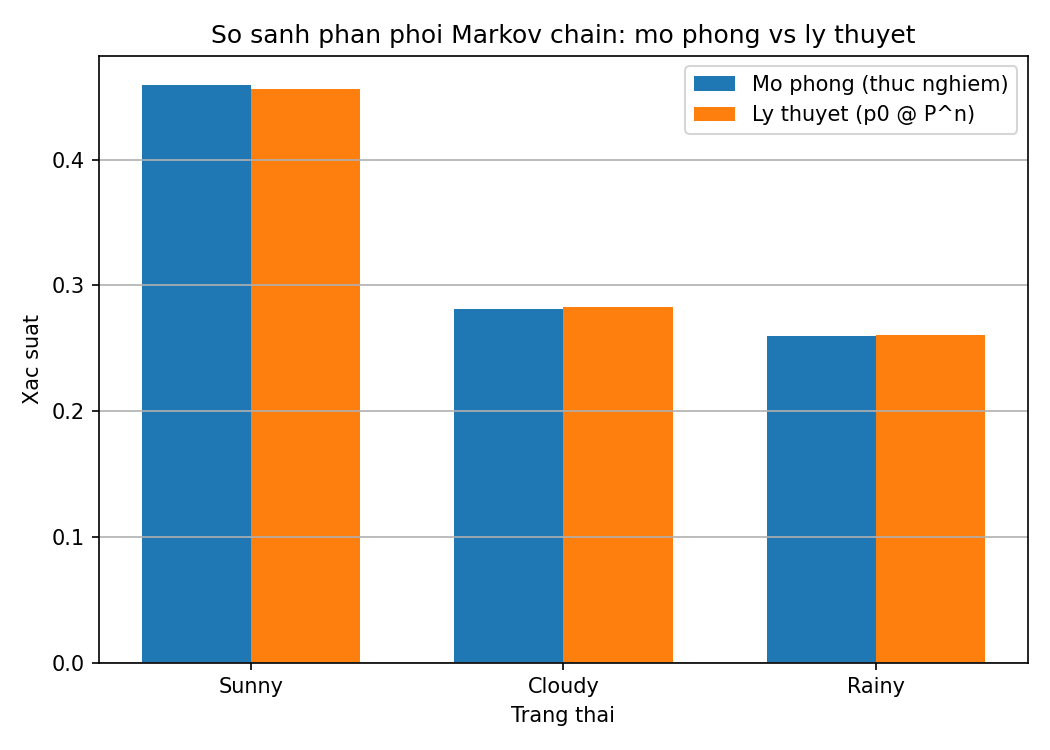

In [5]:
from IPython.display import Image
Image(filename="../figures/markov_distribution.png")

## Phần B - Reward, Return, Discount Factor

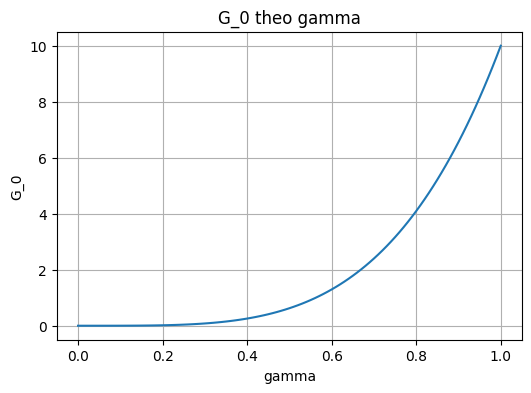

In [6]:
rewards = [0, 0, 0, 0, 10]
gammas = np.linspace(0, 1, 101)
G0 = [compute_return(rewards, g) for g in gammas]

plt.figure(figsize=(6,4))
plt.plot(gammas, G0)
plt.title("G_0 theo gamma"); plt.xlabel("gamma"); plt.ylabel("G_0"); plt.grid(True)
plt.show()

## Phần C - MDP nhỏ (2 state)

In [7]:
from bai12 import P as mdp_P, N_STATES, N_ACTIONS
validate_mdp(mdp_P, N_STATES, N_ACTIONS)
print("MDP hop le.")

MDP hop le.


## Phần D - Khám phá model FrozenLake

In [8]:
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=True)
env.reset()
print("n_states =", env.observation_space.n, " n_actions =", env.action_space.n)
describe_state(env, 0)

n_states = 16  n_actions = 4
--- State 0 ---
  Action 0 (LEFT):
    prob=0.333  next_state= 0  reward=0  terminated=False
    prob=0.333  next_state= 0  reward=0  terminated=False
    prob=0.333  next_state= 4  reward=0  terminated=False
  Action 1 (DOWN):
    prob=0.333  next_state= 0  reward=0  terminated=False
    prob=0.333  next_state= 4  reward=0  terminated=False
    prob=0.333  next_state= 1  reward=0  terminated=False
  Action 2 (RIGHT):
    prob=0.333  next_state= 4  reward=0  terminated=False
    prob=0.333  next_state= 1  reward=0  terminated=False
    prob=0.333  next_state= 0  reward=0  terminated=False
  Action 3 (UP):
    prob=0.333  next_state= 1  reward=0  terminated=False
    prob=0.333  next_state= 0  reward=0  terminated=False
    prob=0.333  next_state= 0  reward=0  terminated=False


## Phần E - Bellman Backup và Policy Evaluation

Hoi tu sau 71 iterations
[[0.0123561  0.01042443 0.01933841 0.00947773]
 [0.01478703 0.         0.03889444 0.        ]
 [0.03260246 0.08433763 0.13781085 0.        ]
 [0.         0.17034482 0.43357944 0.        ]]


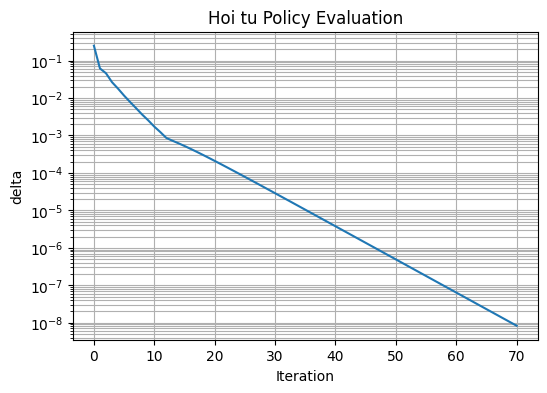

In [9]:
n_states = env.observation_space.n
n_actions = env.action_space.n
uniform_policy = np.ones((n_states, n_actions)) / n_actions

V_eval, n_iter, deltas = policy_evaluation_with_history(env, uniform_policy, gamma=0.99, theta=1e-8)
print(f"Hoi tu sau {n_iter} iterations")
print(V_eval.reshape(4,4))

plt.figure(figsize=(6,4))
plt.plot(deltas); plt.yscale("log")
plt.title("Hoi tu Policy Evaluation"); plt.xlabel("Iteration"); plt.ylabel("delta")
plt.grid(True, which="both")
plt.show()

## Phần F - Policy Improvement và Policy Iteration

In [10]:
policy_pi, V_pi, n_iter_pi = policy_iteration(env, gamma=0.99, theta=1e-8)
print(f"Policy Iteration hoi tu sau {n_iter_pi} iterations")
print_frozenlake_policy(env, policy_pi)

Policy Iteration converged after 7 iterations.
Policy Iteration hoi tu sau 7 iterations
← ↑ ↑ ↑
← H ← H
↑ ↓ ← H
H → ↓ G


'← ↑ ↑ ↑\n← H ← H\n↑ ↓ ← H\nH → ↓ G'

## Phần G - Value Iteration

Value Iteration hoi tu sau 438 iterations
← ↑ ↑ ↑
← H ← H
↑ ↓ ← H
H → ↓ G


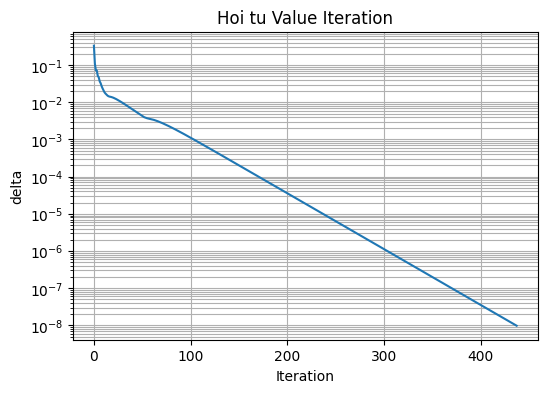

In [11]:
V_vi, n_iter_vi, deltas_vi = value_iteration(env, gamma=0.99, theta=1e-8)
policy_vi = greedy_policy_from_value(env, V_vi, gamma=0.99)
print(f"Value Iteration hoi tu sau {n_iter_vi} iterations")
print_frozenlake_policy(env, policy_vi)

plt.figure(figsize=(6,4))
plt.plot(deltas_vi); plt.yscale("log")
plt.title("Hoi tu Value Iteration"); plt.xlabel("Iteration"); plt.ylabel("delta")
plt.grid(True, which="both")
plt.show()

## Phần H - Đánh giá và so sánh thuật toán

In [12]:
rng = np.random.default_rng(42)
random_policy = rng.integers(0, n_actions, size=n_states)

for name, pol in [("Random", random_policy), ("Value Iteration", policy_vi), ("Policy Iteration", policy_pi)]:
    stats = evaluate_policy_by_simulation(env, pol, n_episodes=1000, seed=42)
    print(name, stats)

Random {'success_rate': 0.0, 'mean_reward': 0.0, 'mean_length': 6.026, 'min_length': 2, 'max_length': 24}


Value Iteration {'success_rate': 0.752, 'mean_reward': 0.752, 'mean_length': 44.319, 'min_length': 6, 'max_length': 100}


Policy Iteration {'success_rate': 0.752, 'mean_reward': 0.752, 'mean_length': 44.319, 'min_length': 6, 'max_length': 100}


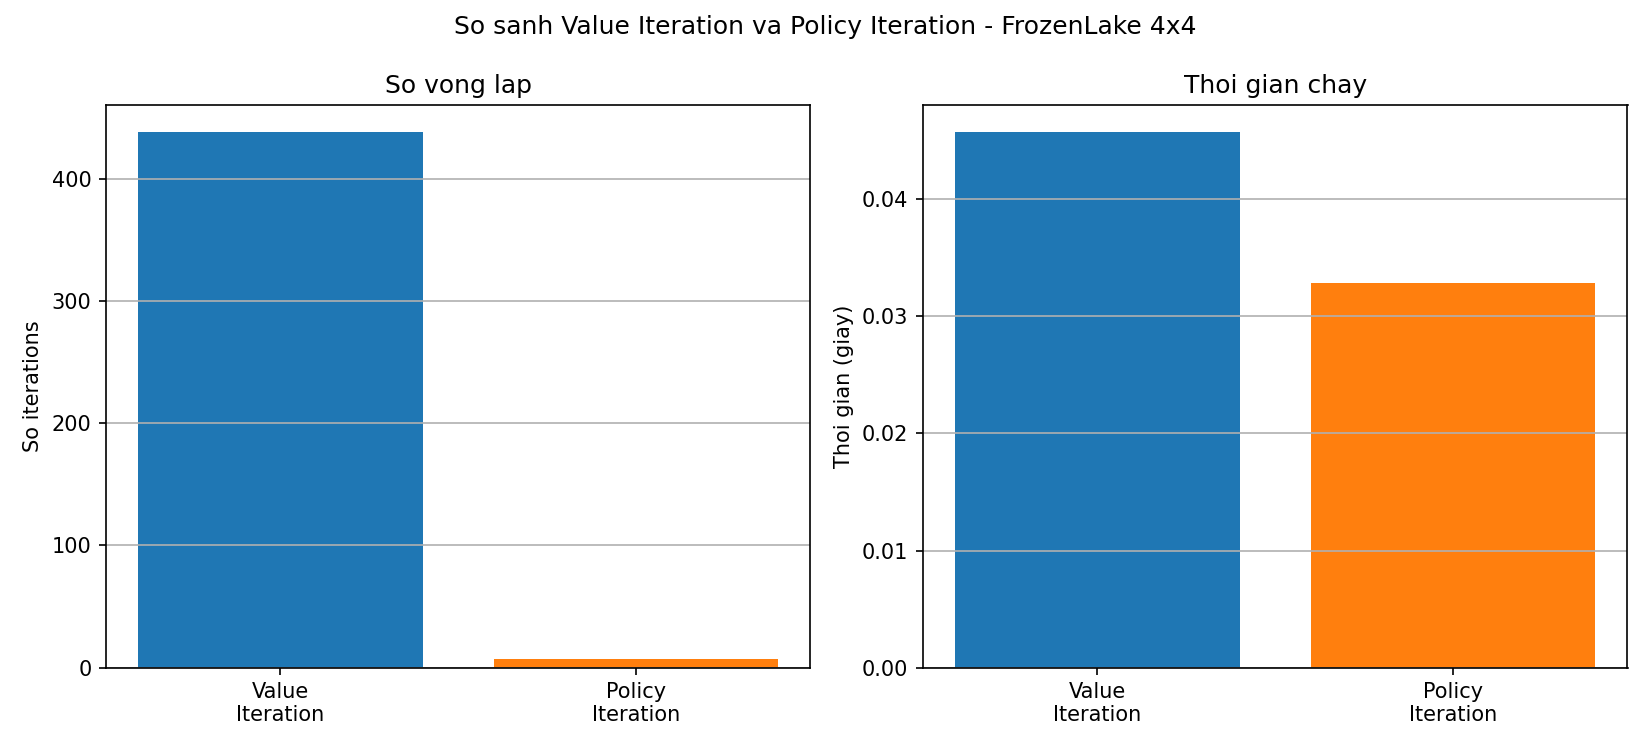

In [13]:
from IPython.display import Image
Image(filename="../figures/algorithm_comparison.png")

**Bảng so sánh (chạy trực tiếp từ `src/bai35.py` / `src/main.py`):**

| Thuật toán | Số vòng lặp | Thời gian (s) | Success rate | Mean reward |
|---|---:|---:|---:|---:|
| Value Iteration | 438 | ~0.048 | 0.752 | 0.752 |
| Policy Iteration | 7 | ~0.033 | 0.752 | 0.752 |

**Nhận xét (8 dòng):** xem chi tiết trong output của `src/bai35.py`, tóm
tắt: cả hai hội tụ về cùng optimal policy/value function; Value Iteration
cần nhiều sweep hơn nhưng mỗi sweep rẻ; Policy Iteration cần ít "vòng lặp
ngoài" hơn nhưng mỗi vòng chứa cả một Policy Evaluation lặp nhiều sweep;
trên FrozenLake 4x4 (bài toán nhỏ) thời gian chạy hai thuật toán tương
đương nhau; success rate/mean reward giống hệt nhau vì cùng chính sách tối
ưu; lựa chọn thuật toán trong thực tế phụ thuộc kích thước không gian
trạng thái và yêu cầu tốc độ hội tụ.

## Bài 36 - Mini-project (xem `src/main.py`)

In [14]:
import main as lab_main
vi_result, pi_result = lab_main.main(n_eval_episodes=1000)

=== Dynamic Programming Solver - FrozenLake-4x4 (is_slippery=True) ===

[Value Iteration] hoi tu sau 438 iterations trong 0.0680s
Value table:
[[0.542  0.4988 0.4707 0.4569]
 [0.5585 0.     0.3583 0.    ]
 [0.5918 0.6431 0.6152 0.    ]
 [0.     0.7417 0.8628 0.    ]]
Policy:
← ↑ ↑ ↑
← H ← H
↑ ↓ ← H
H → ↓ G


Da luu bieu do hoi tu tai: /home/claude/Lab02/src/../figures/value_iteration_convergence.png

Policy Iteration converged after 7 iterations.
[Policy Iteration] hoi tu sau 7 policy iterations trong 0.0355s
Value table:
[[0.542  0.4988 0.4707 0.4569]
 [0.5585 0.     0.3583 0.    ]
 [0.5918 0.6431 0.6152 0.    ]
 [0.     0.7417 0.8628 0.    ]]
Policy:
← ↑ ↑ ↑
← H ← H
↑ ↓ ← H
H → ↓ G


Da luu bieu do hoi tu tai: /home/claude/Lab02/src/../figures/policy_iteration_convergence.png

=== Danh gia bang simulation (1000 episodes) ===



Value Iteration:
  success_rate: 0.752
  mean_reward: 0.752
  mean_length: 44.319
  min_length: 6
  max_length: 100

Policy Iteration:
  success_rate: 0.752
  mean_reward: 0.752
  mean_length: 44.319
  min_length: 6
  max_length: 100

=== So sanh Value Iteration vs Policy Iteration ===
| Thuat toan | So vong lap | Thoi gian (s) | Success rate | Mean reward |
|---|---:|---:|---:|---:|
| Value Iteration | 438 | 0.0680 | 0.752 | 0.752 |
| Policy Iteration | 7 | 0.0355 | 0.752 | 0.752 |


---
# Câu hỏi lý thuyết

**1. Markov property là gì?**

Là tính chất 'không nhớ': xác suất chuyển sang trạng thái kế tiếp chỉ phụ thuộc vào trạng thái hiện tại (và action, nếu có), không phụ thuộc vào toàn bộ lịch sử trước đó: `P(S_{t+1} | S_t, S_{t-1}, ..., S_0) = P(S_{t+1} | S_t)`.

**2. Markov chain khác MDP như thế nào?**

Markov chain chỉ có state và transition probability giữa các state, không có action và reward. MDP thêm action (agent có thể tác động vào quá trình chuyển trạng thái) và reward (tín hiệu phản hồi để agent học chính sách tối ưu).

**3. Transition probability là gì?**

Là xác suất chuyển từ state s, thực hiện action a, sang state kế tiếp s' (và nhận reward r): p(s', r | s, a).

**4. Vì sao tổng transition probability của một (state, action) phải bằng 1?**

Vì đó là một phân phối xác suất đầy đủ trên tập các state kế tiếp có thể xảy ra — chắc chắn agent sẽ đi đến MỘT trong các next_state đó, nên tổng xác suất của tất cả khả năng phải bằng 1.

**5. Return khác immediate reward như thế nào?**

Immediate reward R_{t+1} chỉ là phần thưởng nhận được ngay sau một bước. Return G_t là tổng (có chiết khấu) của TẤT CẢ reward từ thời điểm t trở về sau, phản ánh lợi ích dài hạn chứ không chỉ tức thời.

**6. Discount factor có vai trò gì?**

Gamma kiểm soát mức độ agent coi trọng reward tương lai so với reward hiện tại, đồng thời đảm bảo return hội tụ (hữu hạn) trong các bài toán có episode vô hạn hoặc liên tục.

**7. Khi gamma = 0, agent quan tâm điều gì?**

Agent chỉ quan tâm đến reward tức thời (immediate reward), hoàn toàn bỏ qua hậu quả tương lai (myopic/greedy về mặt thời gian).

**8. Khi gamma gần 1, reward xa trong tương lai ảnh hưởng thế nào?**

Reward ở tương lai xa gần như được coi trọng ngang bằng reward hiện tại, agent trở nên 'nhìn xa' (far-sighted), sẵn sàng đánh đổi lợi ích ngắn hạn để đạt lợi ích dài hạn lớn hơn.

**9. Policy là gì?**

Policy pi là một hàm ánh xạ từ state sang action (deterministic) hoặc sang phân phối xác suất trên các action (stochastic), mô tả cách agent hành xử tại mỗi state.

**10. Deterministic policy khác stochastic policy thế nào?**

Deterministic policy chọn đúng MỘT action cho mỗi state: pi(s) = a. Stochastic policy đưa ra một phân phối xác suất pi(a|s) trên các action, agent chọn action theo phân phối đó.

**11. V(s) biểu diễn điều gì?**

State-value function V_pi(s) là kỳ vọng của return G_t khi bắt đầu từ state s và tuân theo policy pi từ đó về sau: V_pi(s) = E_pi[G_t | S_t=s].

**12. Q(s,a) biểu diễn điều gì?**

State-action value function Q_pi(s,a) là kỳ vọng return khi ở state s, chọn action a, sau đó tuân theo policy pi: Q_pi(s,a) = E_pi[G_t | S_t=s, A_t=a].

**13. Bellman equation có tính đệ quy ở điểm nào?**

Giá trị của một state được biểu diễn qua giá trị của các state kế tiếp: V(s) = ... + gamma*V(s'). Đây là công thức đệ quy vì V xuất hiện ở cả hai vế (dưới dạng V(s) và V(s')).

**14. Bellman expectation khác Bellman optimality thế nào?**

Bellman expectation tính giá trị TRUNG BÌNH theo policy pi hiện tại (có trọng số pi(a|s)). Bellman optimality lấy MAX qua tất cả action (không phụ thuộc policy cụ thể), mô tả giá trị của policy tối ưu.

**15. Dynamic Programming cần biết thông tin gì về môi trường?**

Cần biết đầy đủ transition model p(s', r | s, a) (model-based): mọi next_state có thể xảy ra, xác suất và reward tương ứng cho mọi cặp (state, action).

**16. Policy Evaluation dùng để làm gì?**

Tính hàm giá trị V_pi(s) cho một policy pi cố định cho trước, bằng cách lặp Bellman expectation backup cho tới khi hội tụ.

**17. Policy Improvement dùng để làm gì?**

Cải thiện policy hiện tại bằng cách chọn action tham lam (greedy) theo Q(s,a) tính từ V hiện có, đảm bảo policy mới tốt hơn hoặc bằng policy cũ.

**18. Policy Iteration hoạt động như thế nào?**

Lặp lại hai bước: (1) Policy Evaluation để tính V_pi, (2) Policy Improvement để tạo policy mới tham lam theo V_pi, cho đến khi policy không còn thay đổi (policy stable).

**19. Value Iteration hoạt động như thế nào?**

Lặp trực tiếp Bellman optimality backup: V_new(s) = max_a Q(s,a) cho mọi state, cho đến khi V hội tụ; sau đó trích policy tối ưu bằng greedy policy from V.

**20. Value Iteration khác Policy Iteration ở điểm nào?**

Value Iteration không tách riêng bước Policy Evaluation đầy đủ, mà kết hợp evaluation và improvement thành MỘT bước lấy max mỗi sweep — có thể xem là Policy Evaluation chỉ chạy 1 sweep trước khi improve ngay.

**21. Vì sao FrozenLake-v1 thích hợp để minh họa Dynamic Programming?**

Vì FrozenLake là MDP hữu hạn, rời rạc, có transition model biết trước đầy đủ và có thể truy cập trực tiếp (`env.unwrapped.P`), phù hợp với yêu cầu model-based của Dynamic Programming.

**22. is_slippery=True làm model thay đổi như thế nào?**

Khi is_slippery=True, mỗi action không dẫn đến chính xác một next_state mà có xác suất trượt sang các hướng vuông góc, khiến mỗi (state, action) có nhiều transition (thường 3) thay vì 1 transition xác định như khi is_slippery=False.

**23. theta ảnh hưởng thế nào đến số iteration?**

theta càng nhỏ thì điều kiện dừng (delta < theta) càng khắt khe, cần nhiều iteration hơn để đạt độ chính xác đó; theta càng lớn thì thuật toán dừng sớm hơn nhưng kết quả kém chính xác hơn.

**24. Vì sao cần đánh giá optimal policy bằng simulation?**

Value function tính từ DP là giá trị kỳ vọng lý thuyết dựa trên model; simulation (chạy thực tế nhiều episode) giúp kiểm chứng policy hoạt động đúng như mong đợi trong môi trường thực, đo các chỉ số thực tế như success rate, độ dài episode.

**25. Nếu không biết transition model, Dynamic Programming có áp dụng trực tiếp được không? Giải thích.**

Không. Dynamic Programming là phương pháp model-based, cần biết đầy đủ p(s', r | s, a) để tính Bellman backup. Nếu không biết model, phải dùng các phương pháp model-free học từ kinh nghiệm/episode như Monte Carlo, Temporal-Difference Learning, SARSA, Q-Learning.